# BloomWiSARD — Detecção de Anomalias em IoT (TON_IoT Dataset)

Este notebook implementa um modelo **BloomWiSARD** para detecção de anomalias no dataset TON_IoT (UNSW Canberra Cyber), seguindo a mesma estrutura do notebook ClusWisard, adaptada para os parâmetros e API da BloomWiSARD.

## BloomWiSARD

BloomWiSARD substitui as RAMs convencionais do WiSARD por **Bloom Filters** — estruturas probabilísticas compactas que verificam pertinência com baixa taxa de falsos negativos.

### Parâmetros específicos da BloomWiSARD

| Parâmetro | Valores | Descrição |
|-----------|---------|----------|
| `hashMode` | `murmur`, `simhash`, `h3` | Função de hash dos Bloom Filters |
| `numHashes` | `2, 4, 8` | Número de funções de hash por filtro |
| `filterSize` | `16, 64, 256, 1024` | Tamanho (bits) de cada Bloom Filter |

## Tarefas
- **Binária**: normal (0) vs. ataque (1)
- **Multi-classe**: tipo específico de ataque (ddos, injection, password, etc.)


## 0. Instalação

Execute a célula abaixo se estiver em um ambiente sem as dependências instaladas.

In [8]:
# Instale os pacotes necessários (descomente conforme necessário)

# Versão fork com BloomWisard:
# !pip install git+https://github.com/muanlartins/wisardpkg@muanlartins --no-build-isolation

# Se estiver usando o código local:
# !cd /caminho/para/wisardpkg-master && pip install -e . --no-build-isolation

# Demais dependências:
# !pip install pandas numpy scikit-learn matplotlib seaborn

## 1. Imports e Configuração

In [9]:
import wisardpkg as wp
print(wp.__file__)
print(wp.__version__ if hasattr(wp, '__version__') else 'unknown')
print([c for c in dir(wp) if not c.startswith('_')])

c:\Users\mayara\Documents\Estudo\Mestrado\Redes Neurais sem peso\T1_ClusWiSARD-20260521T152614Z-3-001\T1_BloomWisard\venv\lib\site-packages\wisardpkg\__init__.py
2.0.0a7
['BestBleaching', 'BinBase', 'BinInput', 'Bleaching', 'BloomWisard', 'ClassificationBase', 'ClassificationModel', 'ClusRegressionWisard', 'ClusWisard', 'ColorMaskBinarization', 'DataSet', 'Discriminator', 'DistributiveThermometer', 'DynamicThermometer', 'ExponentialMean', 'ExponentialThermometer', 'GaussianThermometer', 'GeometricMean', 'HarmonicMean', 'HarmonicPowerMean', 'KernelCanvas', 'Local2DMapping', 'LogisticMean', 'MappingGenerator', 'Mean', 'MeanThresholding', 'Median', 'Model', 'PowerMean', 'RAMDataHandle', 'RandomMapping', 'RegressionModel', 'RegressionRAMDataHandle', 'RegressionWisard', 'SimpleMean', 'SimpleThermometer', 'StochasticThermometer', 'SupervisedThermometer', 'Synthesizer', 'Thresholding', 'Weighted', 'Wisard', 'config_sufix', 'dataset_sufix', 'ramdata_sufix']


In [10]:
import wisardpkg as wp
print(wp.__file__)
print([c for c in dir(wp) if not c.startswith('_')])

c:\Users\mayara\Documents\Estudo\Mestrado\Redes Neurais sem peso\T1_ClusWiSARD-20260521T152614Z-3-001\T1_BloomWisard\venv\lib\site-packages\wisardpkg\__init__.py
['BestBleaching', 'BinBase', 'BinInput', 'Bleaching', 'BloomWisard', 'ClassificationBase', 'ClassificationModel', 'ClusRegressionWisard', 'ClusWisard', 'ColorMaskBinarization', 'DataSet', 'Discriminator', 'DistributiveThermometer', 'DynamicThermometer', 'ExponentialMean', 'ExponentialThermometer', 'GaussianThermometer', 'GeometricMean', 'HarmonicMean', 'HarmonicPowerMean', 'KernelCanvas', 'Local2DMapping', 'LogisticMean', 'MappingGenerator', 'Mean', 'MeanThresholding', 'Median', 'Model', 'PowerMean', 'RAMDataHandle', 'RandomMapping', 'RegressionModel', 'RegressionRAMDataHandle', 'RegressionWisard', 'SimpleMean', 'SimpleThermometer', 'StochasticThermometer', 'SupervisedThermometer', 'Synthesizer', 'Thresholding', 'Weighted', 'Wisard', 'config_sufix', 'dataset_sufix', 'ramdata_sufix']


In [11]:
import wisardpkg as wp
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
from sklearn.preprocessing import label_binarize
import time
import json
import warnings
from pathlib import Path
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print(f"wisardpkg version: {wp.__version__ if hasattr(wp, '__version__') else 'unknown'}")
print(f"Classes disponíveis: {[c for c in dir(wp) if not c.startswith('_')]}")

assert hasattr(wp, 'BloomWisard'), (
    'BloomWisard nao encontrado em wisardpkg! '
    'Instale o fork: pip install git+https://github.com/muanlartins/wisardpkg@muanlartins --no-build-isolation'
)
print('BloomWisard disponivel.')

wisardpkg version: 2.0.0a7
Classes disponíveis: ['BestBleaching', 'BinBase', 'BinInput', 'Bleaching', 'BloomWisard', 'ClassificationBase', 'ClassificationModel', 'ClusRegressionWisard', 'ClusWisard', 'ColorMaskBinarization', 'DataSet', 'Discriminator', 'DistributiveThermometer', 'DynamicThermometer', 'ExponentialMean', 'ExponentialThermometer', 'GaussianThermometer', 'GeometricMean', 'HarmonicMean', 'HarmonicPowerMean', 'KernelCanvas', 'Local2DMapping', 'LogisticMean', 'MappingGenerator', 'Mean', 'MeanThresholding', 'Median', 'Model', 'PowerMean', 'RAMDataHandle', 'RandomMapping', 'RegressionModel', 'RegressionRAMDataHandle', 'RegressionWisard', 'SimpleMean', 'SimpleThermometer', 'StochasticThermometer', 'SupervisedThermometer', 'Synthesizer', 'Thresholding', 'Weighted', 'Wisard', 'config_sufix', 'dataset_sufix', 'ramdata_sufix']
BloomWisard disponivel.


In [29]:
print([m for m in dir(wp.BloomWisard) if not m.startswith('_')])

['classify', 'getHashMode', 'getNumBits', 'getNumHashes', 'getNumberOfRAMS', 'getRawVotes', 'getsizeof', 'json', 'rank', 'reset', 'score', 'train']


In [12]:
# ── Caminhos ──────────────────────────────────────────────────────────────────
DATA_PATH = Path(r'C:\Users\mayara\Documents\Estudo\Mestrado\Redes Neurais sem peso\datasets\Train_Test_IoT_dataset')
RESULTS_PATH = Path('results/bloomwisard')
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

# ── Reprodutibilidade ─────────────────────────────────────────────────────────
SEED        = 0
TRAIN_RATIO = 0.70

# ── Datasets disponíveis ──────────────────────────────────────────────────────
DATASETS = {
    'Fridge'      : 'Train_Test_IoT_Fridge.csv',
    'GPS_Tracker' : 'Train_Test_IoT_GPS_Tracker.csv',
    'Motion_Light': 'Train_Test_IoT_Motion_Light.csv',
    'Garage_Door' : 'Train_Test_IoT_Garage_Door.csv',
    'Modbus'      : 'Train_Test_IoT_Modbus.csv',
    'Thermostat'  : 'Train_Test_IoT_Thermostat.csv',
    'Weather'     : 'Train_Test_IoT_Weather.csv',
}

# ── Grade de hiperparâmetros BloomWiSARD ──────────────────────────────────────
HASH_MODES   = ['murmur', 'simhash', 'h3']
NUM_HASHES   = [2, 4, 8]
FILTER_SIZES = [16, 64, 256, 1024]

# ── Parâmetros de binarização (mesmos do ClusWisard) ──────────────────────────
THERM_TYPES = ['Simple', 'Distributive', 'Gaussian', 'Exponential']
THERM_SIZES = [2, 4, 8, 16, 32, 64]
ADDR_SIZES  = [4, 8, 12, 16, 20, 24, 28, 32]

TASKS = ['binary', 'multiclass']
print('Configuracao carregada.')
print(f'  hashMode   : {HASH_MODES}')
print(f'  numHashes  : {NUM_HASHES}')
print(f'  filterSize : {FILTER_SIZES}')

Configuracao carregada.
  hashMode   : ['murmur', 'simhash', 'h3']
  numHashes  : [2, 4, 8]
  filterSize : [16, 64, 256, 1024]


## 2. Definição das Features por Dataset

Idêntica ao notebook ClusWisard — o pré-processamento e a binarização são compartilhados.

| Dataset | Numéricas | Binárias Int | Binárias Cat | K-árias Cat |
|---------|-----------|--------------|--------------|-------------|
| Fridge | fridge_temperature | — | temp_condition | — |
| GPS_Tracker | latitude, longitude | — | — | — |
| Motion_Light | — | motion_status | light_status | — |
| Garage_Door | — | sphone_signal | door_state | — |
| Modbus | FC1, FC2, FC3, FC4 | — | — | — |
| Thermostat | current_temperature | thermostat_status | — | — |
| Weather | temperature, pressure, humidity | — | — | — |

**Colunas excluídas**: `date`, `time` (vazamento temporal)

In [13]:
DATASET_FEATURES = {
    'Fridge': {
        'numeric'    : ['fridge_temperature'],
        'binary_int' : [],
        'binary_cat' : ['temp_condition'],
        'kary_cat'   : [],
    },
    'GPS_Tracker': {
        'numeric'    : ['latitude', 'longitude'],
        'binary_int' : [],
        'binary_cat' : [],
        'kary_cat'   : [],
    },
    'Motion_Light': {
        'numeric'    : [],
        'binary_int' : ['motion_status'],
        'binary_cat' : ['light_status'],
        'kary_cat'   : [],
    },
    'Garage_Door': {
        'numeric'    : [],
        'binary_int' : ['sphone_signal'],
        'binary_cat' : ['door_state'],
        'kary_cat'   : [],
    },
    'Modbus': {
        'numeric'    : ['fc1_read_input_register', 'fc2_read_discrete_value',
                        'fc3_read_holding_register', 'fc4_read_coil'],
        'binary_int' : [],
        'binary_cat' : [],
        'kary_cat'   : [],
    },
    'Thermostat': {
        'numeric'    : ['current_temperature'],
        'binary_int' : ['thermostat_status'],
        'binary_cat' : [],
        'kary_cat'   : [],
    },
    'Weather': {
        'numeric'    : ['temperature', 'pressure', 'humidity'],
        'binary_int' : [],
        'binary_cat' : [],
        'kary_cat'   : [],
    },
}
print('Features definidas para todos os datasets.')

Features definidas para todos os datasets.


## 3. Pré-processamento

In [14]:
def clean_df(df):
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].str.strip().str.lower()
    if 'sphone_signal' in df.columns:
        mapping = {'0': 0, '1': 1, 'false': 0, 'true': 1, 0: 0, 1: 1}
        df['sphone_signal'] = df['sphone_signal'].map(mapping).astype('Int64')
    if 'label' in df.columns:
        df['label'] = df['label'].astype(int)
    return df


def load_dataset(name, task='binary'):
    path = DATA_PATH / DATASETS[name]
    df = pd.read_csv(path, encoding='utf-8-sig')
    df = clean_df(df)
    drop_cols = [c for c in ['date', 'time'] if c in df.columns]
    df = df.drop(columns=drop_cols)
    X = df.drop(columns=['label', 'type'])
    y = df['label'].astype(str) if task == 'binary' else df['type']
    return X, y


X_demo, y_demo = load_dataset('Fridge', 'binary')
print(f'Fridge — Shape: {X_demo.shape}')
print(f'Features: {list(X_demo.columns)}')
print(f'Distribuicao de labels (binary):\n{y_demo.value_counts()}')

Fridge — Shape: (39944, 2)
Features: ['fridge_temperature', 'temp_condition']
Distribuicao de labels (binary):
label
1    24944
0    15000
Name: count, dtype: int64


In [15]:
print(f"{'Dataset':<15} {'Amostras':>10} {'Labels binario':>18} {'Tipos de ataque':>8}")
print('-' * 60)
for name in DATASETS:
    X, y_bin = load_dataset(name, 'binary')
    _, y_multi = load_dataset(name, 'multiclass')
    n_attacks = len(y_multi.unique()) - 1
    dist = y_bin.value_counts()
    n0, n1 = dist.get('0', 0), dist.get('1', 0)
    print(f"{name:<15} {len(X):>10,} {f'{n0:,} / {n1:,}':>18} {n_attacks:>8}")

Dataset           Amostras     Labels binario Tipos de ataque
------------------------------------------------------------
Fridge              39,944    15,000 / 24,944        6
GPS_Tracker         38,960    15,000 / 23,960        7
Motion_Light        39,488    15,000 / 24,488        7
Garage_Door         39,587    15,000 / 24,587        7
Modbus              31,106    15,000 / 16,106        5
Thermostat          32,774    15,000 / 17,774        6
Weather             39,260    15,000 / 24,260        7


## 4. Pipeline de Binarização

Idêntico ao ClusWisard — a entrada da BloomWiSARD também é um vetor binário `{0,1}^n`.

| Tipo de feature | Codificação | Bits |
|-----------------|-------------|------|
| Numérica | Termômetro (n bits) | `therm_size` por feature |
| Binária inteira (0/1) | Passagem direta | 1 bit |
| Binária categórica (2 valores) | 0/1 por ordem lexicográfica | 1 bit |
| K-ária categórica (k>2) | One-hot | k bits |

In [16]:
def build_cat_encoders(X_train, features):
    encoders = {}
    for feat in features['binary_cat'] + features['kary_cat']:
        unique_vals = sorted(X_train[feat].dropna().unique())
        encoders[feat] = {v: i for i, v in enumerate(unique_vals)}
    return encoders


def build_thermometer(therm_type, therm_size, X_train_numeric):
    data_matrix = X_train_numeric.values.tolist()
    n_feat = len(X_train_numeric.columns)
    if therm_type == 'Simple':
        mins = X_train_numeric.min().tolist()
        maxs = X_train_numeric.max().tolist()
        for i in range(n_feat):
            if mins[i] == maxs[i]:
                maxs[i] = mins[i] + 1.0
        return wp.DynamicThermometer(thermometerSizes=[therm_size]*n_feat, minimum=mins, maximum=maxs)
    elif therm_type == 'Distributive':
        therm = wp.DistributiveThermometer(thermometerSize=therm_size)
        therm.fit(data_matrix)
    elif therm_type == 'Gaussian':
        therm = wp.GaussianThermometer(thermometerSize=therm_size)
        therm.fit(data_matrix)
    elif therm_type == 'Exponential':
        therm = wp.ExponentialThermometer(thermometerSize=therm_size)
        therm.fit(data_matrix)
    else:
        raise ValueError(f'Termometro desconhecido: {therm_type}')
    return therm


def binarize_row(row, features, therm, cat_encoders):
    bits = []
    if features['numeric']:
        numeric_vals = [float(row[f]) for f in features['numeric']]
        bits.extend(therm.transform(numeric_vals).list())
    for feat in features['binary_int']:
        val = row[feat]
        bits.append(int(val) if not pd.isna(val) else 0)
    for feat in features['binary_cat']:
        bits.append(cat_encoders[feat].get(str(row[feat]).strip(), 0))
    for feat in features['kary_cat']:
        encoder = cat_encoders[feat]
        k = len(encoder)
        one_hot = [0] * k
        idx = encoder.get(str(row[feat]).strip())
        if idx is not None:
            one_hot[idx] = 1
        bits.extend(one_hot)
    return bits


def build_wisard_dataset(X, y, features, therm, cat_encoders):
    ds = wp.DataSet()
    for idx in range(len(X)):
        row = X.iloc[idx]
        bits = binarize_row(row, features, therm, cat_encoders)
        ds.add(bits, str(y.iloc[idx]))
    return ds


def count_input_bits(dataset_name, therm_size, X_train):
    feat = DATASET_FEATURES[dataset_name]
    return (
        len(feat['numeric']) * therm_size
        + len(feat['binary_int']) + len(feat['binary_cat'])
        + sum(len(X_train[f].dropna().unique()) for f in feat['kary_cat'])
    )


print('Funcoes de binarizacao definidas.')
print('\nBits de entrada por dataset (therm_size=8):')
for name in DATASETS:
    X, _ = load_dataset(name)
    X_tr, _, _, _ = train_test_split(X, pd.Series([0]*len(X)), test_size=0.3, random_state=SEED)
    bits = count_input_bits(name, 8, X_tr)
    print(f'  {name:<15}: {bits:>4} bits')

Funcoes de binarizacao definidas.

Bits de entrada por dataset (therm_size=8):
  Fridge         :    9 bits
  GPS_Tracker    :   16 bits
  Motion_Light   :    2 bits
  Garage_Door    :    2 bits
  Modbus         :   32 bits
  Thermostat     :    9 bits
  Weather        :   24 bits


## 5. Métricas de Avaliação

In [17]:
def compute_metrics(y_true, y_pred, all_scores, classes, task):
    metrics = {
        'accuracy'          : accuracy_score(y_true, y_pred),
        'precision_macro'   : precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro'      : recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro'          : f1_score(y_true, y_pred, average='macro', zero_division=0),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_weighted'   : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_weighted'       : f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }
    try:
        classes_sorted = sorted(list(classes))
        score_matrix = np.array([
            [s.get(c, 0.0) if isinstance(s, dict) else 0.0 for c in classes_sorted]
            for s in all_scores
        ], dtype=float)
        row_sums = score_matrix.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        prob_matrix = score_matrix / row_sums
        if task == 'binary':
            pos_idx = classes_sorted.index('1') if '1' in classes_sorted else -1
            y_scores = prob_matrix[:, pos_idx] if pos_idx >= 0 else prob_matrix[:, 0]
            y_bin = [1 if l == '1' else 0 for l in y_true]
            metrics['auc_roc'] = float(roc_auc_score(y_bin, y_scores))
        else:
            y_true_bin = label_binarize(y_true, classes=classes_sorted)
            if y_true_bin.shape[1] == 1:
                metrics['auc_roc'] = None
            else:
                metrics['auc_roc'] = float(roc_auc_score(
                    y_true_bin, prob_matrix, multi_class='ovr', average='macro'
                ))
    except Exception as e:
        metrics['auc_roc'] = None
        metrics['_auc_error'] = str(e)
    classes_sorted = sorted(list(classes))
    cm = confusion_matrix(y_true, y_pred, labels=classes_sorted)
    metrics['confusion_matrix'] = cm.tolist()
    metrics['confusion_matrix_labels'] = classes_sorted
    return metrics


def measure_memory(model):
    json_str = model.json()
    n_bytes = len(json_str.encode('utf-8'))
    return {'memory_bytes': n_bytes, 'memory_kb': round(n_bytes / 1024, 2)}


print('Funcoes de metricas definidas.')

Funcoes de metricas definidas.


## 6. Modelo BloomWiSARD — Treinamento e Avaliação

### Como funciona a BloomWiSARD

Cada RAM convencional do WiSARD é substituída por um **Bloom Filter**:

1. **Treinamento**: os endereços das RAMs são inseridos no Bloom Filter da classe correta.
2. **Inferência**: conta-se em quantos filtros o endereço da amostra está presente. A classe com mais votos vence.
3. **Parâmetros**:
   - `hashMode`: família de funções de hash (`murmur`, `simhash`, `h3`)
   - `numHashes`: quantidade de funções de hash por filtro
   - `filterSize`: tamanho em bits do Bloom Filter

In [31]:
def run_experiment(
    dataset_name,
    task,
    therm_type,
    therm_size,
    addr_size,
    hash_mode   = 'murmur',  # 'murmur' | 'simhash' | 'h3'
    num_hashes  = 4,
    filter_size = 512,
):
    features    = DATASET_FEATURES[dataset_name]
    has_numeric = len(features['numeric']) > 0

    X, y = load_dataset(dataset_name, task)
    classes = set(y.unique())

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=1 - TRAIN_RATIO, random_state=SEED, stratify=y
    )

    therm = None
    if has_numeric:
        therm = build_thermometer(therm_type, therm_size, X_train[features['numeric']])

    cat_encoders = build_cat_encoders(X_train, features)

    total_bits = count_input_bits(dataset_name, therm_size if has_numeric else 0, X_train)
    if total_bits == 0 or addr_size > total_bits:
        return None

    train_ds = build_wisard_dataset(X_train, y_train, features, therm, cat_encoders)
    test_ds  = build_wisard_dataset(X_test,  y_test,  features, therm, cat_encoders)

    model = wp.BloomWisard(
        addr_size,              # addressSize
        filter_size,            # numBits (filterSize)
        num_hashes,             # numHashes
        hashMode=hash_mode,     # 'murmur' | 'simhash' | 'h3'
    )

    t0 = time.perf_counter()
    model.train(train_ds)
    train_time_s = time.perf_counter() - t0

    t0 = time.perf_counter()
    predictions = model.classify(test_ds)
    infer_time_s = time.perf_counter() - t0
    infer_latency_us = infer_time_s / len(y_test) * 1e6

    try:
        all_scores = model.rank(test_ds)
    except Exception:
        all_scores = [{} for _ in range(len(y_test))]

    y_true = list(y_test.astype(str))
    y_pred = [str(p) for p in predictions]
    metrics = compute_metrics(y_true, y_pred, all_scores, classes, task)
    memory  = measure_memory(model)

    return {
        'dataset'          : dataset_name,
        'task'             : task,
        'thermometer_type' : therm_type if has_numeric else 'N/A',
        'thermometer_size' : therm_size if has_numeric else 0,
        'address_size'     : addr_size,
        'total_input_bits' : total_bits,
        'hash_mode'        : hash_mode,   # ← agora salvo
        'num_hashes'       : num_hashes,
        'filter_size'      : filter_size,
        'n_train'          : len(y_train),
        'n_test'           : len(y_test),
        'train_time_s'     : round(train_time_s, 5),
        'infer_latency_us' : round(infer_latency_us, 4),
        **memory,
        **metrics,
    }

print('Funcao run_experiment() para BloomWiSARD definida.')

Funcao run_experiment() para BloomWiSARD definida.


## 7. Experimento Demonstrativo (Único)

Valida o pipeline completo antes do grid search.

In [33]:
print('=' * 65)
print('Experimento demonstrativo:')
print('  Dataset    : Fridge / binary')
print('  Termometro : Distributive(8), addr=8')
print('  BloomWiSARD: hashMode=murmur, numHashes=4, filterSize=64')
print('=' * 65)

demo_result = run_experiment(
    dataset_name = 'Fridge',
    task         = 'binary',
    therm_type   = 'Distributive',
    therm_size   = 8,
    addr_size    = 8,
    hash_mode    = 'murmur',
    num_hashes   = 4,
    filter_size  = 64,
)

if demo_result:
    print(f'Bits de entrada : {demo_result["total_input_bits"]}')
    print(f'Acuracia        : {demo_result["accuracy"]:.4f}')
    print(f'F1 Macro        : {demo_result["f1_macro"]:.4f}')
    print(f'F1 Weighted     : {demo_result["f1_weighted"]:.4f}')
    print(f'AUC-ROC         : {demo_result.get("auc_roc")}')
    print(f'Tempo treino    : {demo_result["train_time_s"]:.4f}s')
    print(f'Latencia infer. : {demo_result["infer_latency_us"]:.2f}us/amostra')
    print(f'Memoria         : {demo_result["memory_kb"]:.2f}KB')
    print('\nMatriz de Confusao:')
    cm = np.array(demo_result['confusion_matrix'])
    labels = demo_result['confusion_matrix_labels']
    print(pd.DataFrame(cm, index=labels, columns=labels))
else:
    print('Experimento invalido (addr_size > total_bits)')

Experimento demonstrativo:
  Dataset    : Fridge / binary
  Termometro : Distributive(8), addr=8
  BloomWiSARD: hashMode=murmur, numHashes=4, filterSize=64
Bits de entrada : 9
Acuracia        : 0.5407
F1 Macro        : 0.4996
F1 Weighted     : 0.5353
AUC-ROC         : 0.5005831403289981
Tempo treino    : 0.0089s
Latencia infer. : 0.85us/amostra
Memoria         : 0.10KB

Matriz de Confusao:
      0     1
0  1522  2978
1  2526  4958


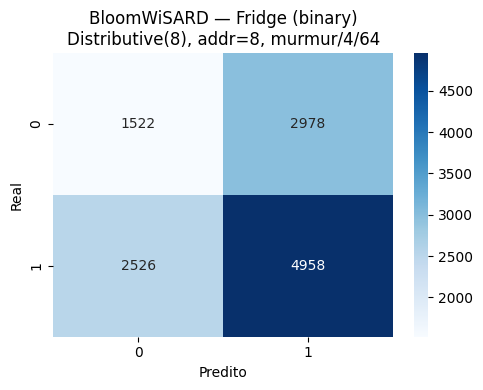

In [35]:
if demo_result:
    fig, ax = plt.subplots(figsize=(5, 4))
    cm_arr = np.array(demo_result['confusion_matrix'])
    labels = demo_result['confusion_matrix_labels']
    sns.heatmap(cm_arr, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title('BloomWiSARD — Fridge (binary)\nDistributive(8), addr=8, murmur/4/64')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predito')
    plt.tight_layout()
    plt.savefig(RESULTS_PATH / 'demo_confusion_matrix.png', dpi=150)
    plt.show()

## 8. Grid Search de Hiperparâmetros

| Dimensão | Valores |
|----------|---------|
| `hashMode` | murmur, simhash, h3 |
| `numHashes` | 2, 4, 8 |
| `filterSize` | 16, 64, 256, 1024 |

Combinadas com os parâmetros de binarização, o grid completo pode levar horas. Use `QUICK_MODE=True` para validação rápida.

In [36]:
QUICK_MODE = True  # True = grid reduzido | False = grid completo

if QUICK_MODE:
    RUN_THERM_TYPES  = ['Distributive', 'Gaussian']
    RUN_THERM_SIZES  = [8, 16]
    RUN_ADDR_SIZES   = [4, 8, 16]
    RUN_HASH_MODES   = HASH_MODES
    RUN_NUM_HASHES   = NUM_HASHES
    RUN_FILTER_SIZES = FILTER_SIZES
else:
    RUN_THERM_TYPES  = THERM_TYPES
    RUN_THERM_SIZES  = THERM_SIZES
    RUN_ADDR_SIZES   = ADDR_SIZES
    RUN_HASH_MODES   = HASH_MODES
    RUN_NUM_HASHES   = NUM_HASHES
    RUN_FILTER_SIZES = FILTER_SIZES

n_bloom = len(RUN_HASH_MODES) * len(RUN_NUM_HASHES) * len(RUN_FILTER_SIZES)
n_binar = len(RUN_THERM_TYPES) * len(RUN_THERM_SIZES) * len(RUN_ADDR_SIZES)
print(f'Configuracoes BloomWiSARD  : {n_bloom}')
print(f'Configuracoes binarizacao  : {n_binar}')
print(f'Total por dataset/task     : {n_bloom * n_binar}')

Configuracoes BloomWiSARD  : 36
Configuracoes binarizacao  : 12
Total por dataset/task     : 432


In [37]:
def run_grid_search(
    dataset_name,
    task,
    therm_types=None,
    therm_sizes=None,
    addr_sizes=None,
    hash_modes=None,
    num_hashes_list=None,
    filter_sizes=None,
    verbose=True,
):
    if therm_types     is None: therm_types     = RUN_THERM_TYPES
    if therm_sizes     is None: therm_sizes     = RUN_THERM_SIZES
    if addr_sizes      is None: addr_sizes      = RUN_ADDR_SIZES
    if hash_modes      is None: hash_modes      = RUN_HASH_MODES
    if num_hashes_list is None: num_hashes_list = RUN_NUM_HASHES
    if filter_sizes    is None: filter_sizes    = RUN_FILTER_SIZES

    features    = DATASET_FEATURES[dataset_name]
    has_numeric = len(features['numeric']) > 0
    eff_ttype   = therm_types if has_numeric else ['Simple']
    eff_tsize   = therm_sizes if has_numeric else [1]

    results = []
    configs = list(product(eff_ttype, eff_tsize, addr_sizes,
                           hash_modes, num_hashes_list, filter_sizes))
    total = len(configs)

    for i, (tt, ts, asize, hmode, nhash, fsize) in enumerate(configs, 1):
        if verbose:
            print(f'  [{i:4}/{total}] therm={tt:<15}({ts:>2}) addr={asize:>2} | '
                  f'hash={hmode:<8} k={nhash} fsize={fsize:>4}', end=' -> ')
        try:
            result = run_experiment(dataset_name, task, tt, ts, asize, hmode, nhash, fsize)
            if result is None:
                if verbose: print('SKIP')
                continue
            results.append(result)
            if verbose:
                auc = f"{result['auc_roc']:.4f}" if result.get('auc_roc') else 'N/A'
                print(f"acc={result['accuracy']:.4f}  f1={result['f1_macro']:.4f}  auc={auc}")
        except Exception as e:
            if verbose: print(f'ERRO: {e}')
    return results


def save_results(results, dataset_name, task):
    path = RESULTS_PATH / f'{dataset_name}__{task}.json'
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(results, f, indent=2, default=str)
    print(f'  Salvo: {path} ({len(results)} configs)')


print('Funcoes de grid search para BloomWiSARD definidas.')

Funcoes de grid search para BloomWiSARD definidas.


In [38]:
all_results = {}

for dataset_name in DATASETS.keys():
    for task in TASKS:
        key = f'{dataset_name}__{task}'
        print(f'\n{"="*65}')
        print(f' Dataset: {dataset_name}  |  Tarefa: {task}')
        print('='*65)
        results = run_grid_search(dataset_name, task, verbose=True)
        all_results[key] = results
        save_results(results, dataset_name, task)

print('\n' + '='*65)
print('Grid search concluido!')
print(f'Total de configuracoes validas: {sum(len(v) for v in all_results.values())}')


 Dataset: Fridge  |  Tarefa: binary
  [   1/432] therm=Distributive   ( 8) addr= 4 | hash=murmur   k=2 fsize=  16 -> acc=0.5742  f1=0.4892  auc=0.5039
  [   2/432] therm=Distributive   ( 8) addr= 4 | hash=murmur   k=2 fsize=  64 -> acc=0.5448  f1=0.4941  auc=0.4968
  [   3/432] therm=Distributive   ( 8) addr= 4 | hash=murmur   k=2 fsize= 256 -> acc=0.5944  f1=0.4399  auc=0.4959
  [   4/432] therm=Distributive   ( 8) addr= 4 | hash=murmur   k=2 fsize=1024 -> acc=0.5899  f1=0.4450  auc=0.4932
  [   5/432] therm=Distributive   ( 8) addr= 4 | hash=murmur   k=4 fsize=  16 -> acc=0.5237  f1=0.5081  auc=0.5111
  [   6/432] therm=Distributive   ( 8) addr= 4 | hash=murmur   k=4 fsize=  64 -> acc=0.5973  f1=0.4448  auc=0.4962
  [   7/432] therm=Distributive   ( 8) addr= 4 | hash=murmur   k=4 fsize= 256 -> acc=0.5749  f1=0.4860  auc=0.5002
  [   8/432] therm=Distributive   ( 8) addr= 4 | hash=murmur   k=4 fsize=1024 -> acc=0.5973  f1=0.4448  auc=0.4989
  [   9/432] therm=Distributive   ( 8) addr

## 9. Análise dos Resultados

In [39]:
rows = []
for results in all_results.values():
    rows.extend(results)
df_all = pd.DataFrame(rows)

print(f'Total de experimentos: {len(df_all)}')
df_all.head(3)

Total de experimentos: 4032


,dataset,task,thermometer_type,thermometer_size,address_size,total_input_bits,hash_mode,num_hashes,filter_size,n_train,...,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,auc_roc,confusion_matrix,confusion_matrix_labels
0,Fridge,binary,Distributive,8,4,9,murmur,2,16,27960,...,0.574182,0.505364,0.503883,0.489246,0.535608,0.574182,0.541108,0.503883,"[[997, 3503], [1600, 5884]]","[0, 1]"
1,Fridge,binary,Distributive,8,4,9,murmur,2,64,27960,...,0.544810,0.496432,0.496758,0.494075,0.527774,0.544810,0.533968,0.496758,"[[1367, 3133], [2322, 5162]]","[0, 1]"
2,Fridge,binary,Distributive,8,4,9,murmur,2,256,27960,...,0.594376,0.484980,0.494267,0.439941,0.518977,0.594376,0.513170,0.495854,"[[415, 4085], [776, 6708]]","[0, 1]"


In [40]:
display_cols = [
    'dataset', 'task', 'thermometer_type', 'thermometer_size', 'address_size',
    'hash_mode', 'num_hashes', 'filter_size',
    'accuracy', 'f1_macro', 'f1_weighted', 'auc_roc',
    'train_time_s', 'infer_latency_us', 'memory_kb'
]

best = (
    df_all[display_cols]
    .sort_values('f1_macro', ascending=False)
    .groupby(['dataset', 'task'])
    .first()
    .reset_index()
)

print('=' * 90)
print('Melhor configuracao por Dataset/Task — BloomWiSARD (F1 Macro)')
print('=' * 90)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(best.to_string(index=False))

Melhor configuracao por Dataset/Task — BloomWiSARD (F1 Macro)
    dataset       task thermometer_type  thermometer_size  address_size hash_mode  num_hashes  filter_size  accuracy  f1_macro  f1_weighted  auc_roc  train_time_s  infer_latency_us  memory_kb
     Fridge     binary     Distributive                 8             4    murmur           4           16    0.5237    0.5081       0.5299   0.5111        0.0107            0.9978     0.1000
     Fridge multiclass     Distributive                16             8    murmur           2           16    0.2548    0.1246       0.2164   0.4949        0.0122            8.5158     0.1000
GPS_Tracker     binary     Distributive                 8             8    murmur           8         1024    0.8773    0.8669       0.8755   0.8584        0.0093            0.9585     0.1000
GPS_Tracker multiclass     Distributive                 8             4   simhash           8         1024    0.5420    0.3458       0.5462   0.7104        0.0407        

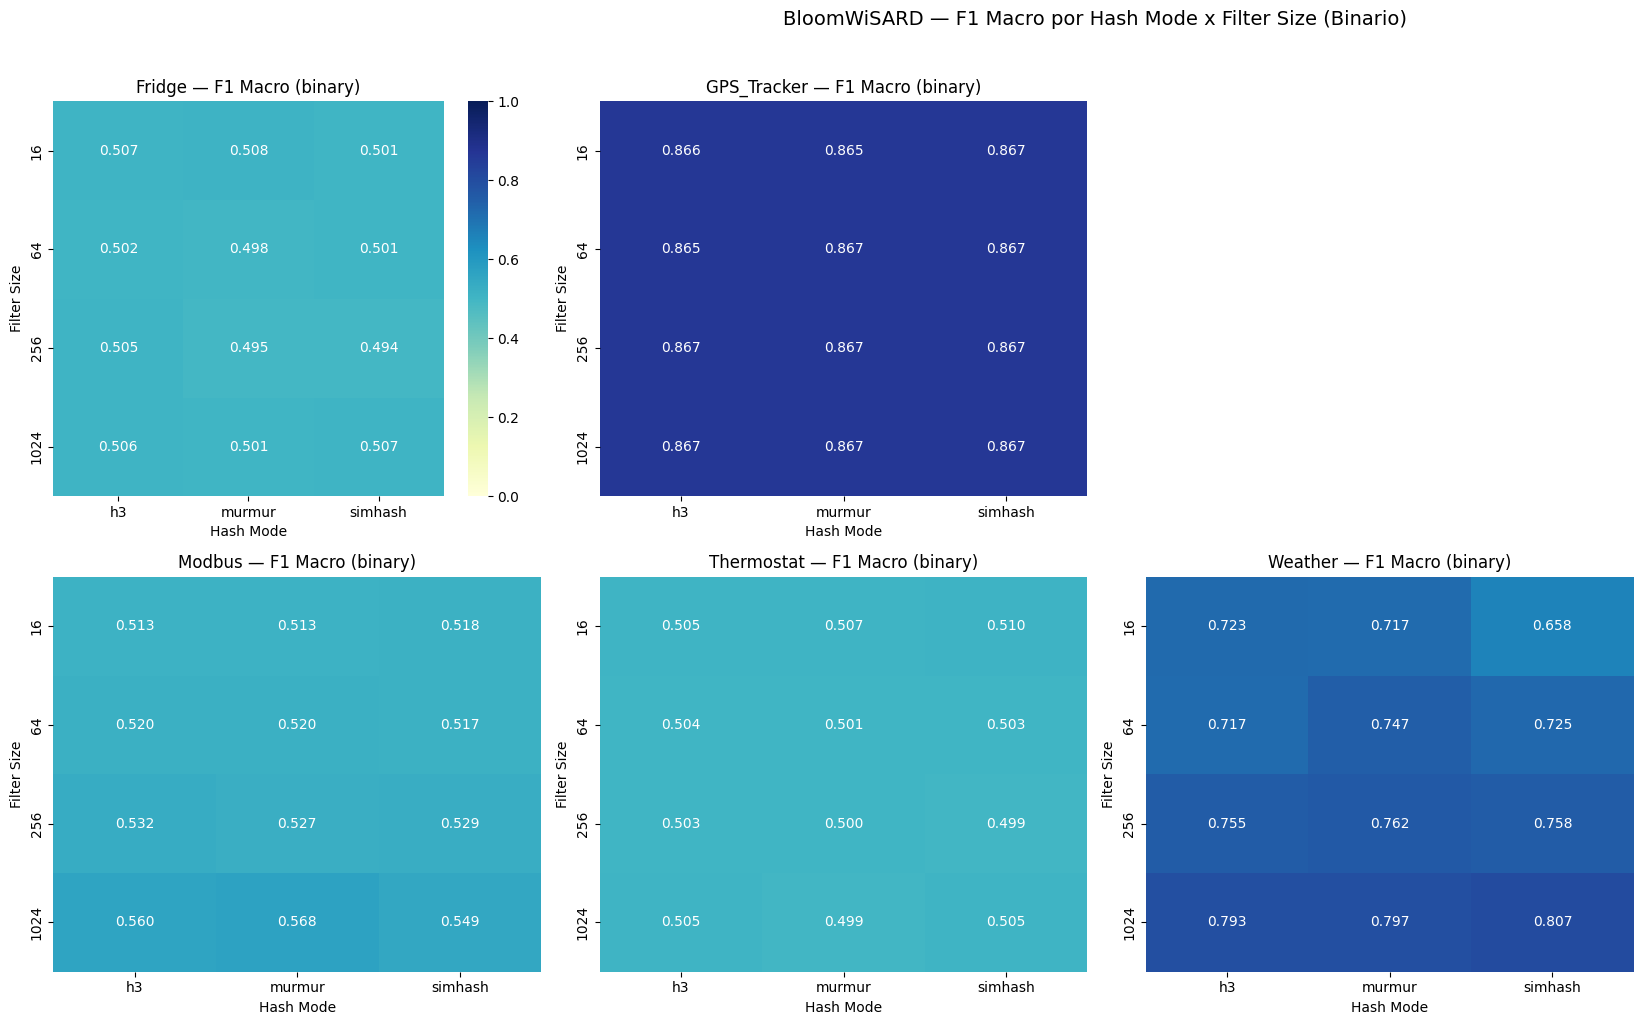

In [41]:
# Heatmap: F1 Macro por hashMode x filterSize (binario)
df_binary = df_all[df_all['task'] == 'binary'].copy()

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, name in enumerate(list(DATASETS.keys())):
    sub = df_binary[df_binary['dataset'] == name]
    if sub.empty:
        axes[i].set_visible(False)
        continue
    pivot = sub.pivot_table(
        values='f1_macro', index='filter_size', columns='hash_mode', aggfunc='max'
    )
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu',
                vmin=0, vmax=1, ax=axes[i], cbar=i==0)
    axes[i].set_title(f'{name} — F1 Macro (binary)')
    axes[i].set_xlabel('Hash Mode')
    axes[i].set_ylabel('Filter Size')

for j in range(len(DATASETS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('BloomWiSARD — F1 Macro por Hash Mode x Filter Size (Binario)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'heatmap_f1_hashmode_filtersize_binary.png', dpi=150, bbox_inches='tight')
plt.show()

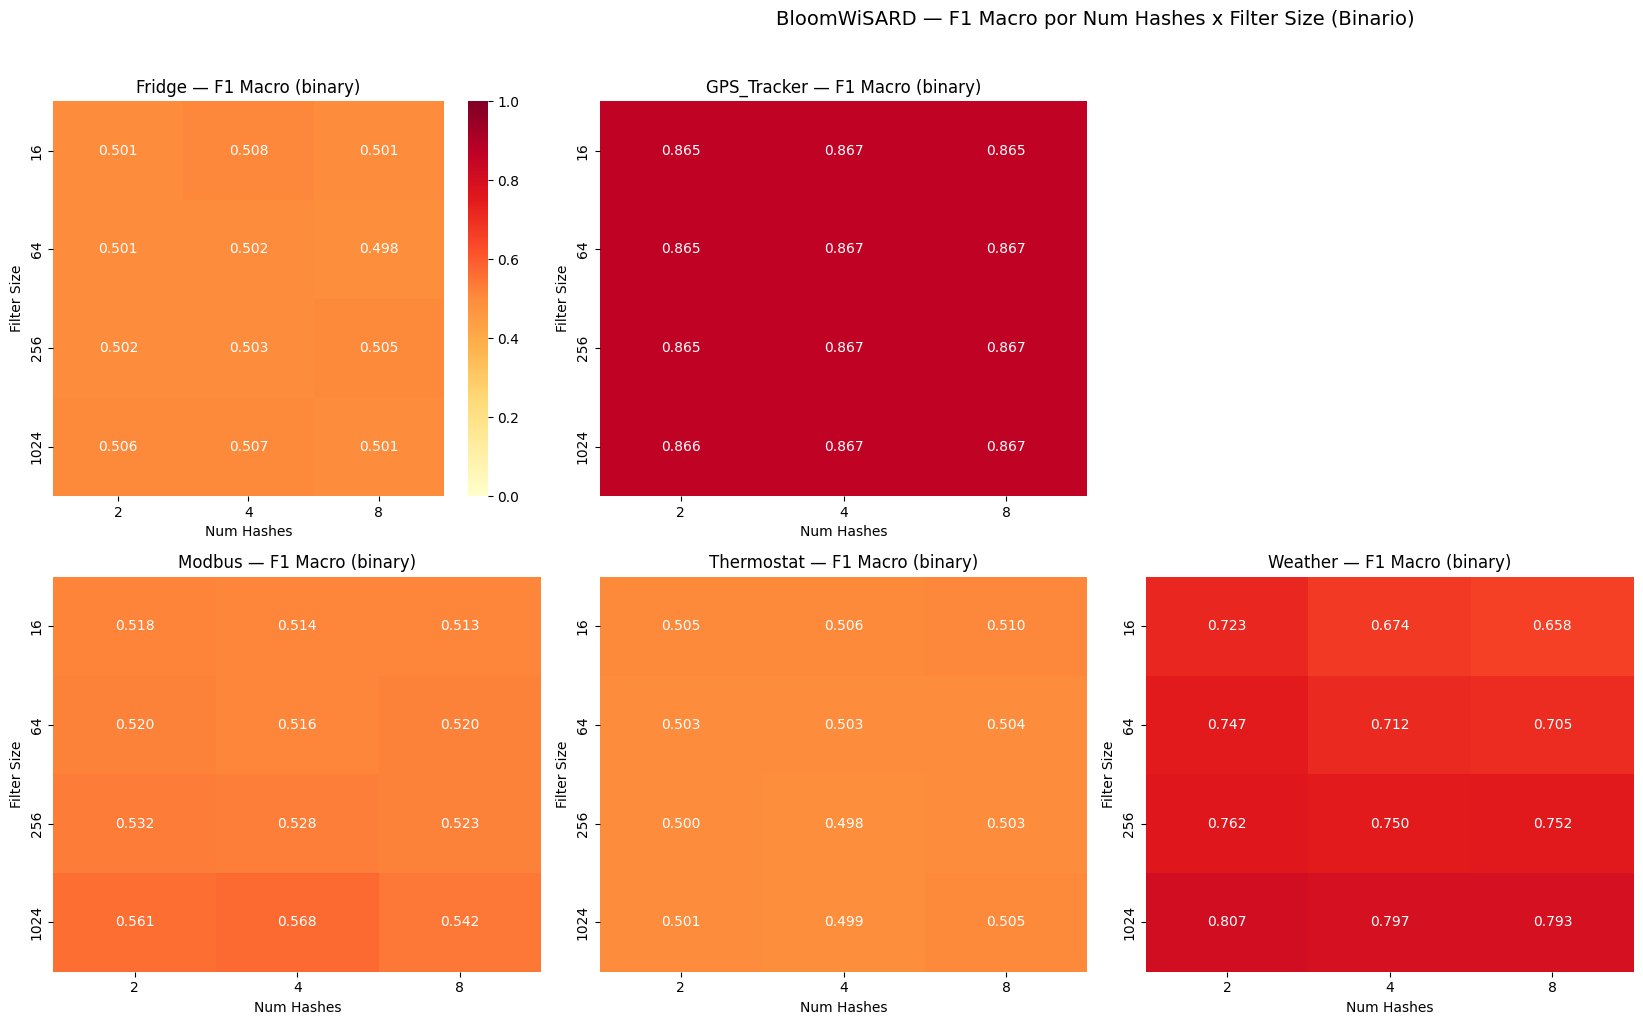

In [42]:
# Heatmap: F1 Macro por numHashes x filterSize (binario)
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, name in enumerate(list(DATASETS.keys())):
    sub = df_binary[df_binary['dataset'] == name]
    if sub.empty:
        axes[i].set_visible(False)
        continue
    pivot = sub.pivot_table(
        values='f1_macro', index='filter_size', columns='num_hashes', aggfunc='max'
    )
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
                vmin=0, vmax=1, ax=axes[i], cbar=i==0)
    axes[i].set_title(f'{name} — F1 Macro (binary)')
    axes[i].set_xlabel('Num Hashes')
    axes[i].set_ylabel('Filter Size')

for j in range(len(DATASETS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('BloomWiSARD — F1 Macro por Num Hashes x Filter Size (Binario)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'heatmap_f1_numhashes_filtersize_binary.png', dpi=150, bbox_inches='tight')
plt.show()

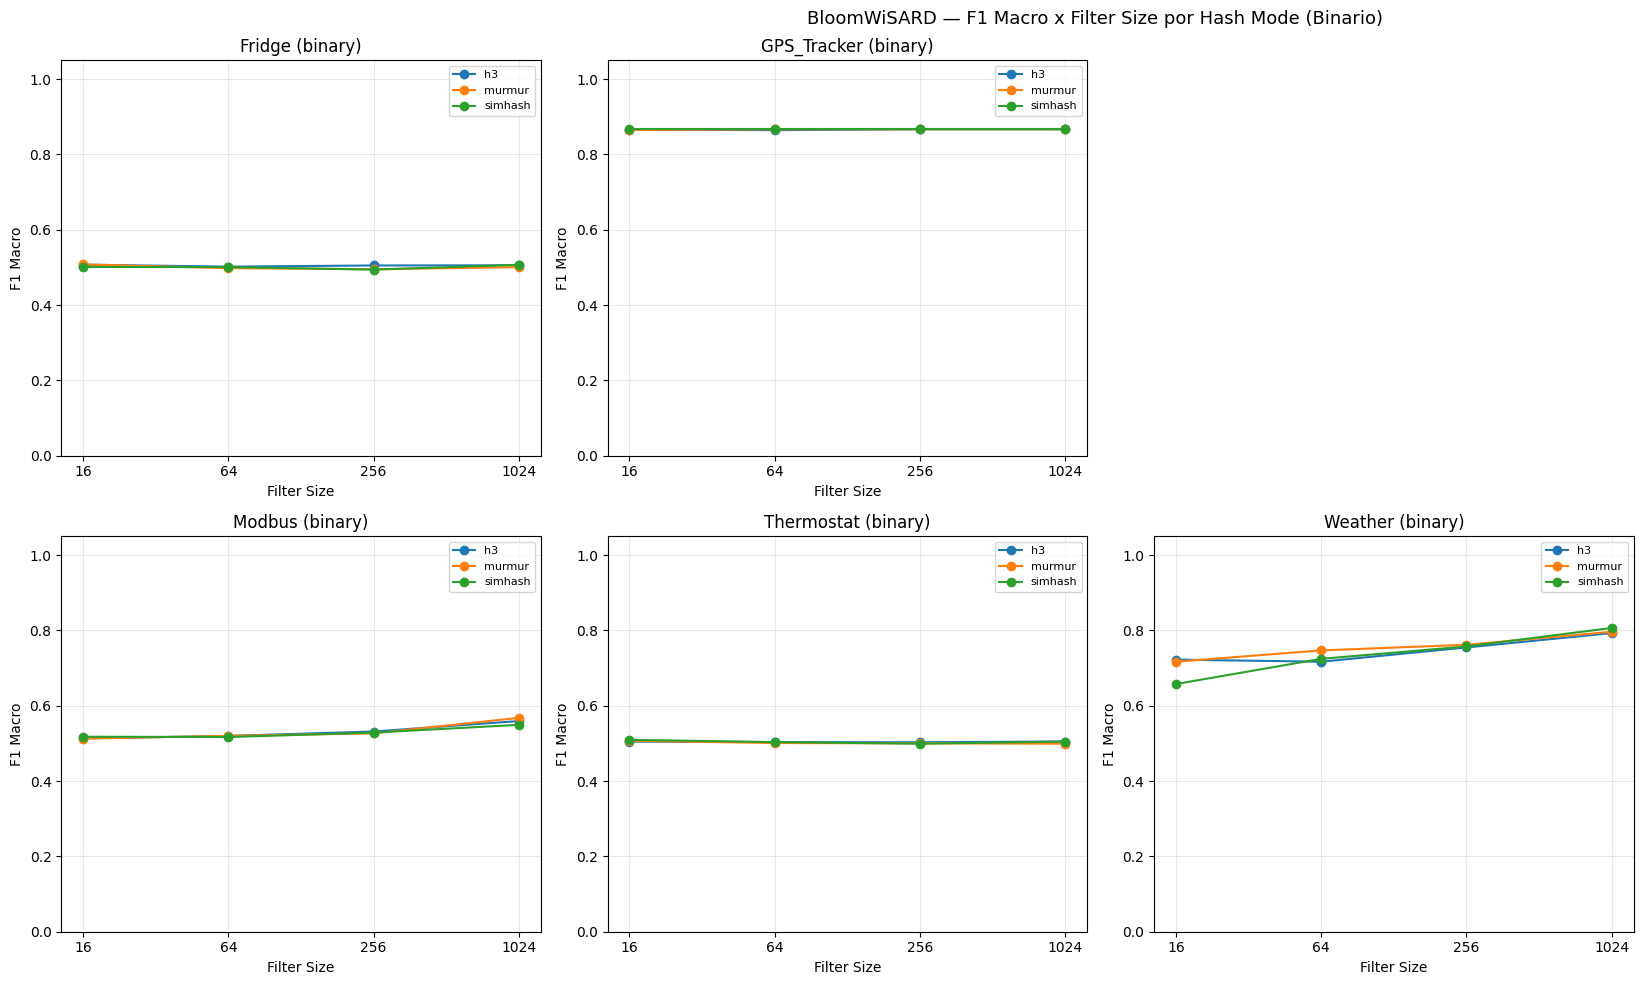

In [43]:
# F1 Macro x filterSize por hashMode (binario)
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, name in enumerate(list(DATASETS.keys())):
    sub = df_binary[df_binary['dataset'] == name]
    if sub.empty:
        axes[i].set_visible(False)
        continue
    grp = sub.groupby(['filter_size', 'hash_mode'])['f1_macro'].max().reset_index()
    for hmode, gdf in grp.groupby('hash_mode'):
        axes[i].plot(gdf['filter_size'].astype(str), gdf['f1_macro'], marker='o', label=hmode)
    axes[i].set_title(f'{name} (binary)')
    axes[i].set_xlabel('Filter Size')
    axes[i].set_ylabel('F1 Macro')
    axes[i].set_ylim(0, 1.05)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

for j in range(len(DATASETS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('BloomWiSARD — F1 Macro x Filter Size por Hash Mode (Binario)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'f1_vs_filtersize_binary.png', dpi=150)
plt.show()

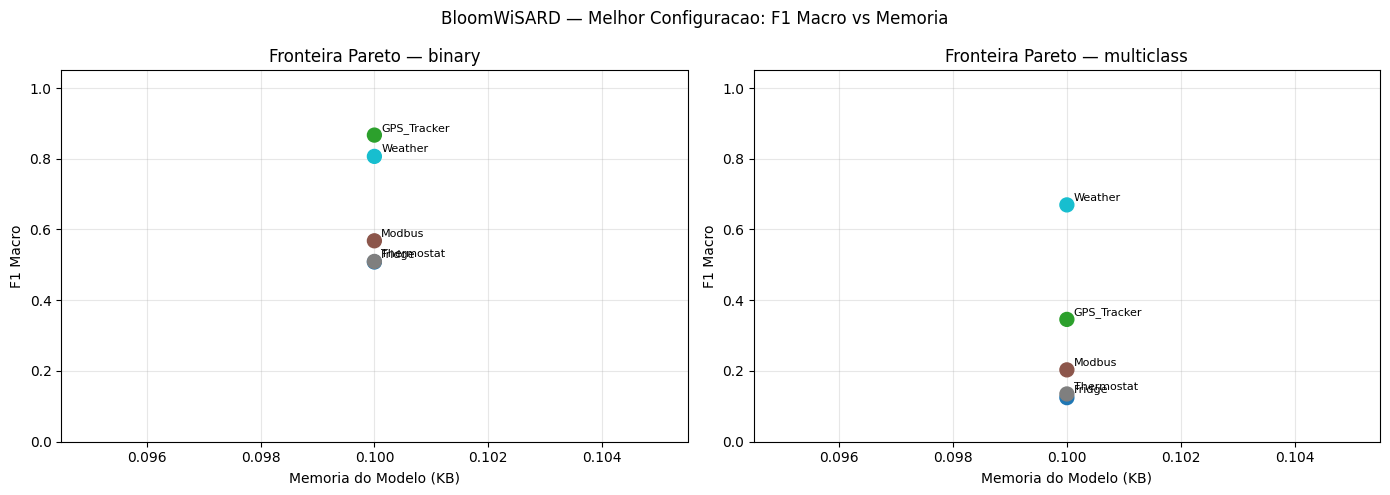

In [44]:
# Pareto: F1 Macro vs Memoria
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task in zip(axes, TASKS):
    best_task = best[best['task'] == task]
    ax.scatter(best_task['memory_kb'], best_task['f1_macro'],
               c=range(len(best_task)), cmap='tab10', s=100, zorder=5)
    for _, row in best_task.iterrows():
        ax.annotate(row['dataset'], (row['memory_kb'], row['f1_macro']),
                    textcoords='offset points', xytext=(5, 3), fontsize=8)
    ax.set_xlabel('Memoria do Modelo (KB)')
    ax.set_ylabel('F1 Macro')
    ax.set_title(f'Fronteira Pareto — {task}')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.suptitle('BloomWiSARD — Melhor Configuracao: F1 Macro vs Memoria')
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'pareto_f1_memory.png', dpi=150)
plt.show()

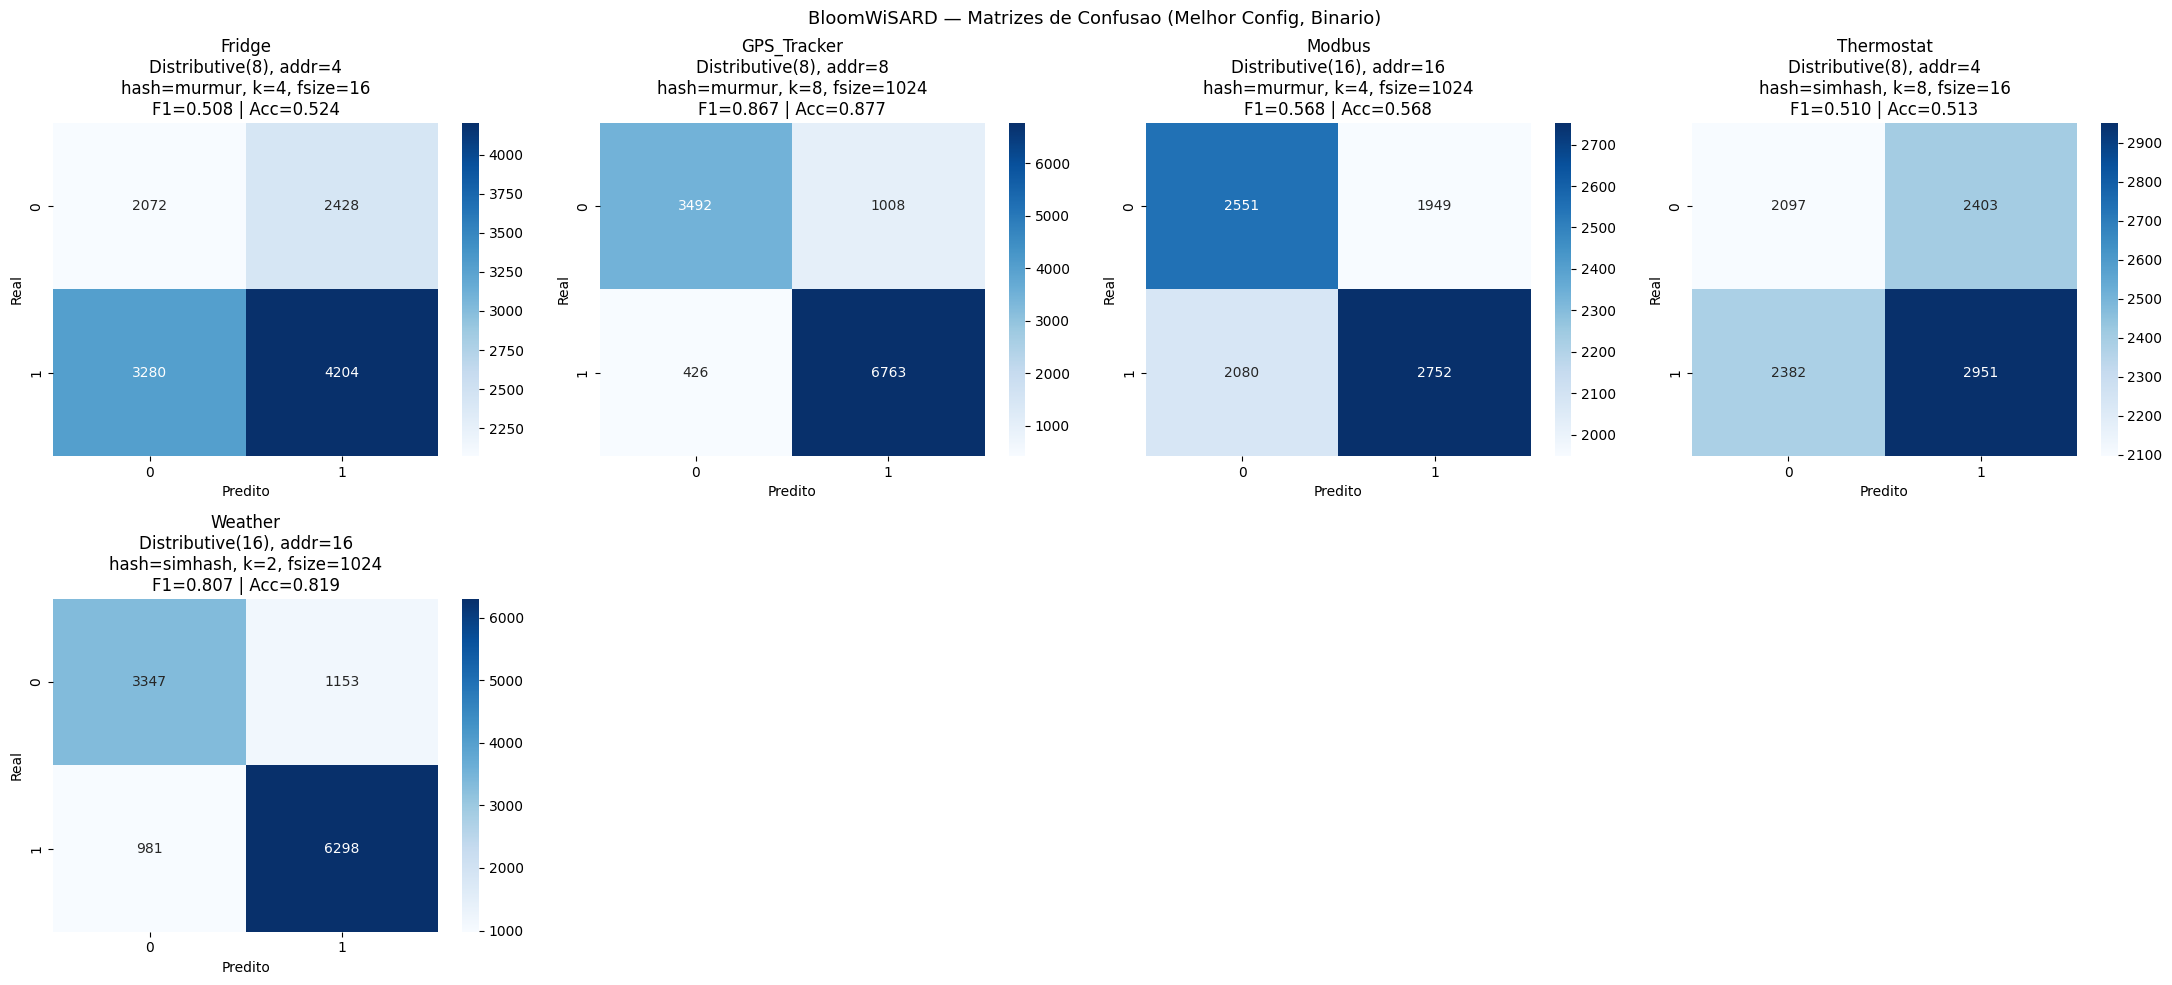

In [45]:
# Matrizes de confusao — melhores configs por dataset (binario)
best_binary = best[best['task'] == 'binary'].copy()
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, (_, row) in enumerate(best_binary.iterrows()):
    name = row['dataset']
    key = f'{name}__binary'
    matching = [
        r for r in all_results.get(key, [])
        if (r.get('thermometer_type') == row['thermometer_type'] and
            r.get('thermometer_size') == row['thermometer_size'] and
            r.get('address_size')     == row['address_size'] and
            r.get('hash_mode')        == row['hash_mode'] and
            r.get('num_hashes')       == row['num_hashes'] and
            r.get('filter_size')      == row['filter_size'])
    ]
    if not matching:
        axes[i].set_visible(False)
        continue
    r = matching[0]
    cm_arr = np.array(r['confusion_matrix'])
    labels = r['confusion_matrix_labels']
    sns.heatmap(cm_arr, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[i])
    axes[i].set_title(
        f"{name}\n{r['thermometer_type']}({r['thermometer_size']}), addr={r['address_size']}\n"
        f"hash={r['hash_mode']}, k={r['num_hashes']}, fsize={r['filter_size']}\n"
        f"F1={r['f1_macro']:.3f} | Acc={r['accuracy']:.3f}"
    )
    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Predito')

for j in range(len(best_binary), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('BloomWiSARD — Matrizes de Confusao (Melhor Config, Binario)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_PATH / 'confusion_matrices_binary.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Análise Multi-classe

In [46]:
df_multi = df_all[df_all['task'] == 'multiclass'].copy()

if df_multi.empty:
    print('Nenhum resultado multi-classe disponivel.')
else:
    best_multi = (
        df_multi[display_cols].sort_values('f1_macro', ascending=False)
        .groupby('dataset').first().reset_index()
    )
    print('=' * 90)
    print('Melhor configuracao por Dataset — Tarefa Multi-classe (BloomWiSARD)')
    print('=' * 90)
    print(best_multi.to_string(index=False))

Melhor configuracao por Dataset — Tarefa Multi-classe (BloomWiSARD)
    dataset       task thermometer_type  thermometer_size  address_size hash_mode  num_hashes  filter_size  accuracy  f1_macro  f1_weighted  auc_roc  train_time_s  infer_latency_us  memory_kb
     Fridge multiclass     Distributive                16             8    murmur           2           16    0.2548    0.1246       0.2164   0.4949        0.0122            8.5158     0.1000
GPS_Tracker multiclass     Distributive                 8             4   simhash           8         1024    0.5420    0.3458       0.5462   0.7104        0.0407           17.0973     0.1000
     Modbus multiclass     Distributive                16            16    murmur           4         1024    0.4488    0.2031       0.3951   0.5560        0.0380           20.3649     0.1000
 Thermostat multiclass     Distributive                16             4        h3           2          256    0.3534    0.1351       0.3075   0.5049        0.0361  

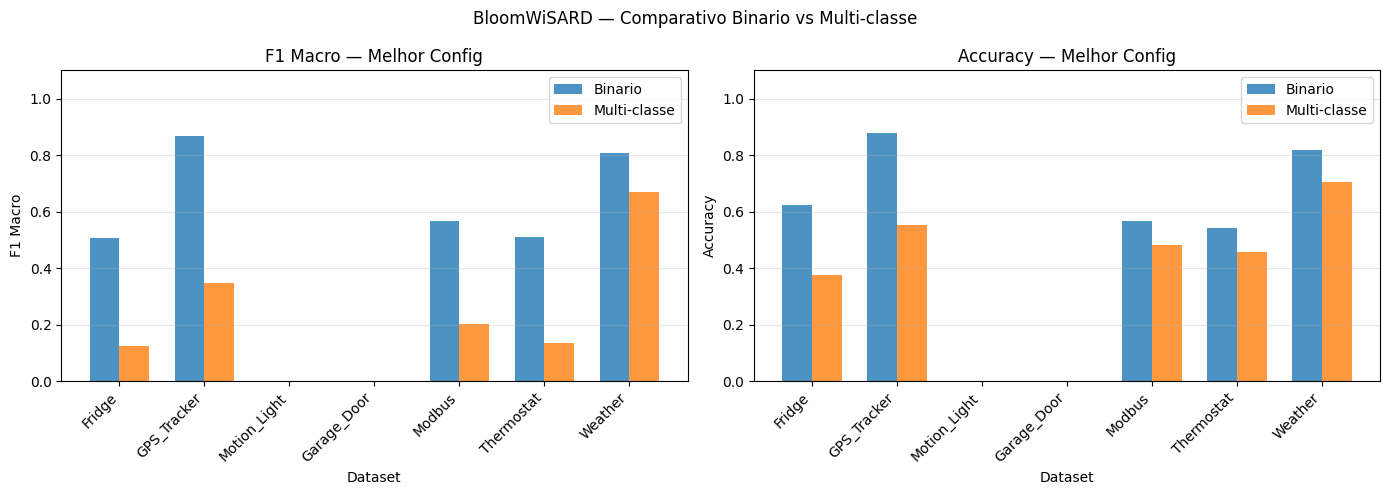

In [47]:
if not df_multi.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric in zip(axes, ['f1_macro', 'accuracy']):
        comparison = pd.DataFrame({'Dataset': list(DATASETS.keys())})
        for task in TASKS:
            vals = []
            for name in DATASETS.keys():
                sub = df_all[(df_all['dataset'] == name) & (df_all['task'] == task)]
                vals.append(sub[metric].max() if not sub.empty else 0.0)
            comparison[task] = vals
        x = np.arange(len(DATASETS))
        width = 0.35
        ax.bar(x - width/2, comparison['binary'], width, label='Binario', alpha=0.8)
        ax.bar(x + width/2, comparison['multiclass'], width, label='Multi-classe', alpha=0.8)
        ax.set_xlabel('Dataset')
        ax.set_ylabel(metric.replace('_', ' ').title())
        ax.set_title(f'{metric.replace("_", " ").title()} — Melhor Config')
        ax.set_xticks(x)
        ax.set_xticklabels(list(DATASETS.keys()), rotation=45, ha='right')
        ax.set_ylim(0, 1.1)
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
    plt.suptitle('BloomWiSARD — Comparativo Binario vs Multi-classe')
    plt.tight_layout()
    plt.savefig(RESULTS_PATH / 'binary_vs_multiclass.png', dpi=150)
    plt.show()

## 11. Salvar Resultados Consolidados

In [48]:
all_path = RESULTS_PATH / 'all_results.json'
with open(all_path, 'w', encoding='utf-8') as f:
    json.dump(all_results, f, indent=2, default=str)
print(f'Resultados consolidados salvos em: {all_path}')

csv_path = RESULTS_PATH / 'all_results.csv'
df_all[display_cols].to_csv(csv_path, index=False)
print(f'CSV salvo em: {csv_path}')

print('\n' + '='*50)
print('RESUMO FINAL — BloomWiSARD')
print('='*50)
print(f'Total de experimentos : {len(df_all)}')
print(f'Datasets              : {list(DATASETS.keys())}')
print(f'Tarefas               : {TASKS}')
print(f'Hash modes testados   : {RUN_HASH_MODES}')
print(f'Num hashes testados   : {RUN_NUM_HASHES}')
print(f'Filter sizes testados : {RUN_FILTER_SIZES}')
print(f'Resultados em         : {RESULTS_PATH}')

if not df_all.empty:
    best_global = df_all.loc[df_all['f1_macro'].idxmax()]
    print('\nMelhor F1 Macro global:')
    print(f'  Dataset     : {best_global["dataset"]}')
    print(f'  Task        : {best_global["task"]}')
    print(f'  Termometro  : {best_global["thermometer_type"]}({best_global["thermometer_size"]})')
    print(f'  Addr Size   : {best_global["address_size"]}')
    print(f'  Hash Mode   : {best_global["hash_mode"]}')
    print(f'  Num Hashes  : {best_global["num_hashes"]}')
    print(f'  Filter Size : {best_global["filter_size"]}')
    print(f'  F1 Macro    : {best_global["f1_macro"]:.4f}')
    print(f'  Acuracia    : {best_global["accuracy"]:.4f}')
    print(f'  AUC-ROC     : {best_global.get("auc_roc")}')

Resultados consolidados salvos em: results\bloomwisard\all_results.json
CSV salvo em: results\bloomwisard\all_results.csv

RESUMO FINAL — BloomWiSARD
Total de experimentos : 4032
Datasets              : ['Fridge', 'GPS_Tracker', 'Motion_Light', 'Garage_Door', 'Modbus', 'Thermostat', 'Weather']
Tarefas               : ['binary', 'multiclass']
Hash modes testados   : ['murmur', 'simhash', 'h3']
Num hashes testados   : [2, 4, 8]
Filter sizes testados : [16, 64, 256, 1024]
Resultados em         : results\bloomwisard

Melhor F1 Macro global:
  Dataset     : GPS_Tracker
  Task        : binary
  Termometro  : Distributive(8)
  Addr Size   : 4
  Hash Mode   : murmur
  Num Hashes  : 4
  Filter Size : 1024
  F1 Macro    : 0.8669
  Acuracia    : 0.8773
  AUC-ROC     : 0.8777988593684796


## Referências

- **WiSARD**: Aleksander, I. et al. (1984). A weightless neural network. *Electronics Letters*.
- **BloomWiSARD**: Bloom Filter applied to WiSARD discriminators for compact probabilistic RAM representation.
- **Bloom Filter**: Bloom, B. H. (1970). Space/time trade-offs in hash coding with allowable errors. *CACM*.
- **TON_IoT**: Moustafa, N. et al. (2021). TON_IoT Datasets. *IEEE Internet of Things Journal*.
- **wisardpkg** (fork com BloomWiSARD): https://github.com/muanlartins/wisardpkg